# Robust Curvature-Aware Spherical Parameterization

Validates the multi-objective pipeline (method 6) with:
- Per-face curvature target areas Ao
- Bijectivity gate metrics
- Parametric triangle quality
- Ao vs achieved area correlation
- SHP export with reconstruction error

In [14]:
import numpy as np
import sys, os
import matplotlib.pyplot as plt
import pyvista as pv

pv.set_jupyter_backend('static')

code_dir = r'C:\Users\Khaled Khairy\Dropbox\Projects\hot\Project_spherical_parameterization\code'
if code_dir not in sys.path:
    sys.path.insert(0, code_dir)

from pySHP.surface_mesh import surface_mesh
from pySHP.utils import readoff
from pySHP.level2.robust_spherical_parameterization import (
    robust_spherical_parameterization, export_robust_shp)
from pySHP.level1.bijectivity_gate import (
    check_bijectivity_gate, compute_achieved_spherical_areas,
    compute_parametric_quality)
from pySHP.level1.target_areas import compute_curvature_target_areas

In [15]:
topic = 'test_set'
file_name = 'mushroom_repaired_03.off'
fn_shape = os.path.join(code_dir, 'Matlab', 'shp_toolbox-main', 'shp_toolbox-main',
                         'test_data', 'off', topic, file_name)
X_orig, F_orig = readoff(fn_shape)
m_orig = surface_mesh(X_orig, F_orig)
m_orig.repair_mesh(verbose=False)
print(f'Input: {len(m_orig.X)} verts, {len(m_orig.F)} faces')

Input: 2002 verts, 4000 faces


In [16]:
weights = dict(lambdaA=1.0, lambda_flip=1e4, lambda1=1e-4, lambda2=1e-2)

# s  = fitted spherical-harmonics surface (main handle for plotting / export)
# m_param = parameterized mesh with (t, p) on the sphere
m_param, s, report = robust_spherical_parameterization(
    m_orig,
    target_faces_final=1500,
    coarse_faces=400,
    weights=weights,
    remesh_input=True,
    optimization_niter=30,
    optimization_step=0.08,
    L_max=16,
    verbose=True,
)

print(f's: shp_surface L_max={s.L_max}, coeffs={len(s.xc)}')
print(f'm_param: {len(m_param.X)} verts, {len(m_param.F)} faces')
print('Acceptance:', report['acceptance'])

Stage 0: Input repair and remesh
Starting mesh repair sequence...
Initial mesh: 2002 vertices, 4000 faces
Removing duplicate vertices and faces...
  No duplicate vertices or faces found
Mesh repair complete: 2002 vertices, 4000 faces
Removing isolated vertices...
  No isolated vertices found
Mesh repair complete: 2002 vertices, 4000 faces
Performing deep mesh cleaning...

Mesh connectivity: Single connected component (4000 faces)

------------------------------------------------------------
Checking and fixing normal/winding consistency...
------------------------------------------------------------
Fixing normal/winding consistency...
  All face normals are already consistent
Mesh repair complete: 2002 vertices, 4000 faces

Mesh repair complete!
Final mesh: 2002 vertices, 4000 faces
Mesh appears to be a closed shape (Euler characteristic = 2)
  remesh_by_curvature -> 1500 faces
remesh_by_curvature: target_faces=1500, curvature_strength=2.0
  Sizing field: L_min=0.0291, L_max=0.0873, r

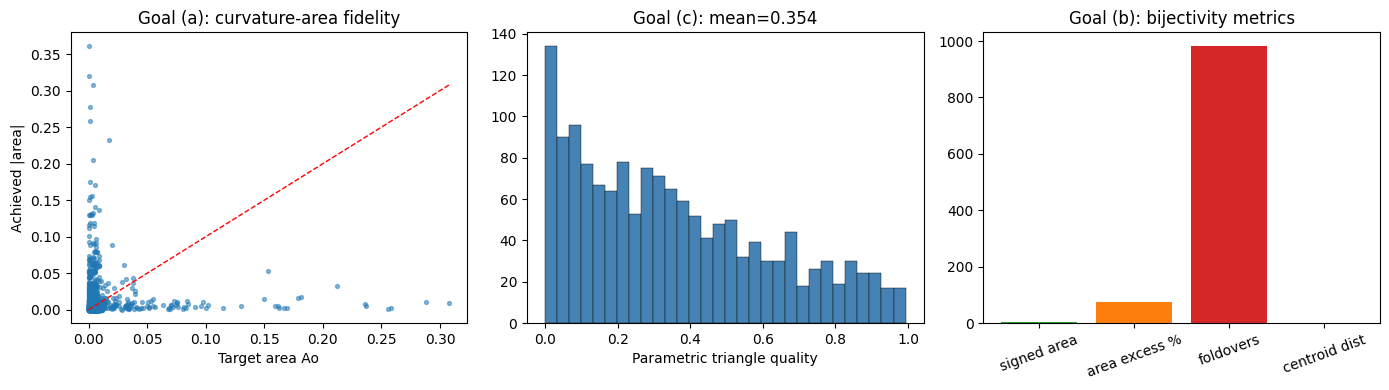

In [17]:
Ao, _ = compute_curvature_target_areas(m_param)
_, achieved = compute_achieved_spherical_areas(m_param)
achieved_abs = np.abs(achieved)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].scatter(Ao, achieved_abs, s=8, alpha=0.5)
axes[0].plot([0, Ao.max()], [0, Ao.max()], 'r--', lw=1)
axes[0].set_xlabel('Target area Ao')
axes[0].set_ylabel('Achieved |area|')
axes[0].set_title('Goal (a): curvature-area fidelity')

qual = compute_parametric_quality(m_param)
axes[1].hist(qual['qualities'], bins=30, color='steelblue', edgecolor='k', lw=0.3)
axes[1].set_xlabel('Parametric triangle quality')
axes[1].set_title(f"Goal (c): mean={qual['mean_quality']:.3f}")

gate = check_bijectivity_gate(m_param)
labels = ['signed area', 'area excess %', 'foldovers', 'centroid dist']
vals = [gate['signed_total_area'], 100*gate['area_excess_rel'],
        gate['n_foldovers'], gate['centroid_dist']]
axes[2].bar(labels, vals, color=['#2ca02c', '#ff7f0e', '#d62728', '#9467bd'])
axes[2].set_title('Goal (b): bijectivity metrics')
axes[2].tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()

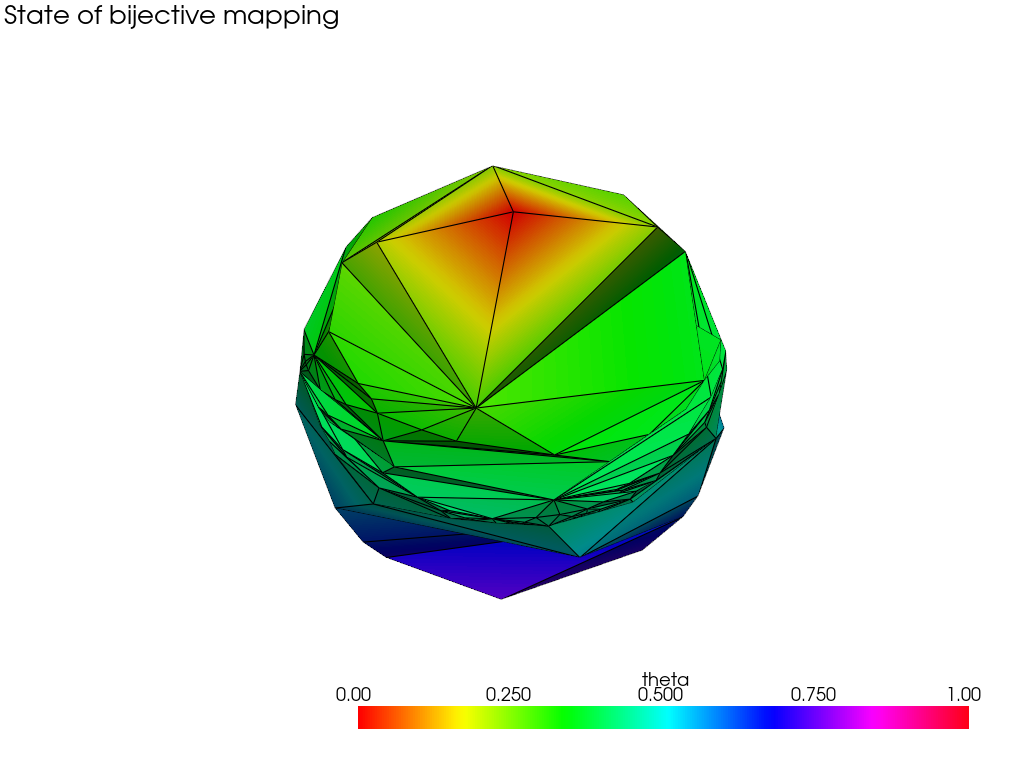

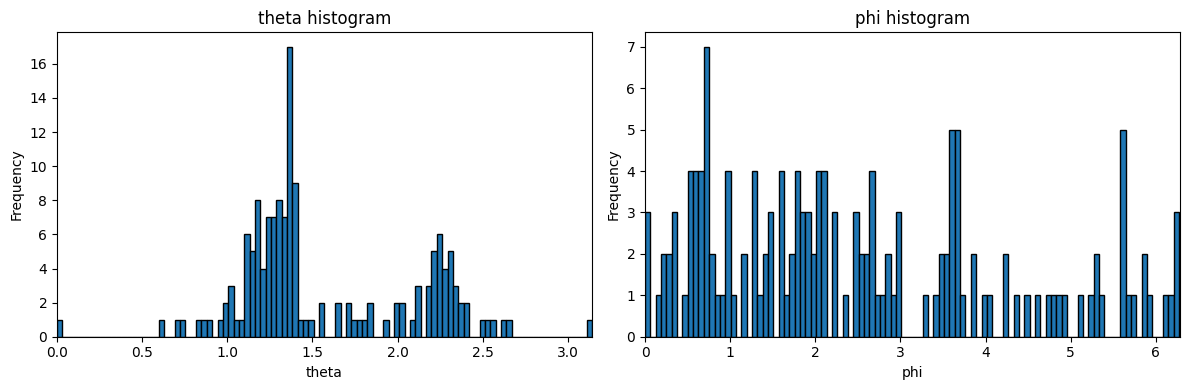

<Figure size 640x480 with 0 Axes>

lambda_flip=1e+02: area excess=145.7%, foldovers=245
lambda_flip=1e+03: area excess=156.7%, foldovers=250
lambda_flip=1e+04: area excess=156.8%, foldovers=250


In [18]:
# Weight sweep (coarse mesh only, fast)
m_dec, vmap = m_orig.curvature_aware_decimation(target_faces=300, verbose=False)
m_dec.optimization_method = 0
m_dec.newton_niter = 0
m_dec.map2sphere()
Ao_dec, _ = compute_curvature_target_areas(m_dec)

from pySHP.level1.newton_multi_objective import newton_multi_objective, default_multi_objective_opts

flip_vals = [1e2, 1e3, 1e4]
sweep = []
for lf in flip_vals:
    opts = default_multi_objective_opts(maxiter=10, lambda_flip=lf, verbose=0)
    t, p, _, _ = newton_multi_objective(m_dec.t.copy(), m_dec.p.copy(), m_dec.F, Ao_dec, opts)
    td = surface_mesh(m_dec.X, m_dec.F)
    td.t, td.p = t, p
    g = check_bijectivity_gate(td)
    sweep.append((lf, g['area_excess_rel'], g['n_foldovers']))

for lf, ex, fo in sweep:
    print(f'lambda_flip={lf:.0e}: area excess={100*ex:.1f}%, foldovers={fo}')

In [22]:
# Optional: save s to disk (does not create s — that happens in the pipeline cell above)
out_shp3 = os.path.join(code_dir, 'pySHP', 'tests', 'robust_parameterized_mesh.shp3')
recon_err = export_robust_shp(m_param, s, out_shp3, verbose=True)
print(f'SHP reconstruction RMS error: {recon_err:.6f}')

Exported spherical harmonics surface to: C:\Users\Khaled Khairy\Dropbox\Projects\hot\Project_spherical_parameterization\code\pySHP\tests\robust_parameterized_mesh.shp3
  L_max: 16
  Number of coefficients: 289
  Components: 3 (x, y, z)
Exported C:\Users\Khaled Khairy\Dropbox\Projects\hot\Project_spherical_parameterization\code\pySHP\tests\robust_parameterized_mesh.shp3, reconstruction RMS=0.138597
SHP reconstruction RMS error: 0.138597


In [23]:
# s = your shp_surface (from the pipeline cell)
print(type(s), 'L_max=', s.L_max)

m_shp, X_shp, F_shp, _, _, _ = s.get_mesh(nico=5)
print(f'm_shp: {len(X_shp)} verts, {len(F_shp)} faces')

# PyVista static backend: displays as PNG in notebook output
m_shp.plot(color='lightblue', show_edges=True)

<class 'pySHP.shp_surface.shp_surface'> 16
